In [4]:
pip install tensorflow pandas numpy yfinance scikit-learn matplotlib ta-lib sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install TA_Lib-0.4.28-cp311-cp311-win_amd64.whl

Processing c:\users\dmlxo\documents\github\ai-stock\models\ta_lib-0.4.28-cp311-cp311-win_amd64.whl
TA-Lib is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd

def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df

def technical_analysis(df):
    analysis = {}
    
    # 이동평균선
    short_ma = talib.SMA(df['Close'], timeperiod=20)
    long_ma = talib.SMA(df['Close'], timeperiod=50)
    
    if short_ma.iloc[-1] > long_ma.iloc[-1]:
        analysis['trend'] = "상승세"
    else:
        analysis['trend'] = "하락세"
    
    # MACD 분석
    macd, signal, _ = talib.MACD(df['Close'])
    if macd.iloc[-1] > signal.iloc[-1]:
        analysis['MACD'] = "강세 신호"
    else:
        analysis['MACD'] = "약세 신호"
    
    # RSI 분석
    rsi = talib.RSI(df['Close'])
    if rsi.iloc[-1] > 70:
        analysis['RSI'] = "과매수"
    elif rsi.iloc[-1] < 30:
        analysis['RSI'] = "과매도"
    else:
        analysis['RSI'] = "중립"
    
    # OBV 분석
    obv = talib.OBV(df['Close'], df['Volume'])
    if obv.iloc[-1] > obv.iloc[-5]:
        analysis['OBV'] = "긍정적 흐름"
    else:
        analysis['OBV'] = "부정적 흐름"
    
    return analysis

def fundamental_analysis(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    info = stock.info
    analysis = {}
    
    # P/E, PBR 지표
    analysis['P/E'] = info.get('trailingPE', 'N/A')
    analysis['PBR'] = info.get('priceToBook', 'N/A')
    
    # 매출 성장률
    revenue_growth = info.get('revenueGrowth', 'N/A')
    if revenue_growth is not None:
        analysis['매출 성장'] = f"{revenue_growth * 100:.2f}%"
    else:
        analysis['매출 성장'] = "데이터 없음"
    
    # 순부채비율 (부채/자산 비율 확인)
    total_debt = info.get('totalDebt', 0)
    total_assets = info.get('totalAssets', 1)
    debt_ratio = total_debt / total_assets if total_assets > 0 else 'N/A'
    analysis['순부채비율'] = f"{debt_ratio:.2%}" if debt_ratio != 'N/A' else "데이터 없음"
    
    return analysis

def valuation_analysis(pe, pbr):
    if pe != 'N/A' and pbr != 'N/A':
        if pe > 25 or pbr > 3:
            return "고평가 가능성 있음"
        else:
            return "적정 가치"
    return "데이터 부족"

def summary_report():
    df = get_stock_data()
    tech_analysis = technical_analysis(df)
    fund_analysis = fundamental_analysis()
    valuation = valuation_analysis(fund_analysis['P/E'], fund_analysis['PBR'])
    
    report = "📊 종합 분석 리포트\n"
    report += f"기술적 분석: {tech_analysis}\n"
    report += f"펀더멘탈 분석: {fund_analysis}\n"
    report += f"현재 가치 평가: {valuation}\n"
    
    return report

# 실행
print(summary_report())

📊 종합 분석 리포트
기술적 분석: {'trend': '하락세', 'MACD': '강세 신호', 'RSI': '중립', 'OBV': '부정적 흐름'}
펀더멘탈 분석: {'P/E': 34.5873, 'PBR': 49.09869, '매출 성장': '4.00%', '순부채비율': '9679899852800.00%'}
현재 가치 평가: 고평가 가능성 있음



📊 **종합 분석 리포트**
**기술적 분석:** {'이동평균선 추세': '하락세', 'MACD': '강세 신호', 'RSI': '중립', 'OBV': '긍정적 흐름'}
**펀더멘탈 분석:** {'P/E': 35.258728, 'PBR': 50.051823, '매출 성장': '4.00%', '순부채비율': '데이터 없음'}
**현재 가치 평가:** 고평가 가능성 있음



C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2894930124.py:115: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2894930124.py:115: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2894930124.py:115: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2894930124.py:115: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2894930124.py:115: UserWarning: Glyph 48143 (\N{HANGUL SYLLABLE MIC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2894930124.py:115: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from fo

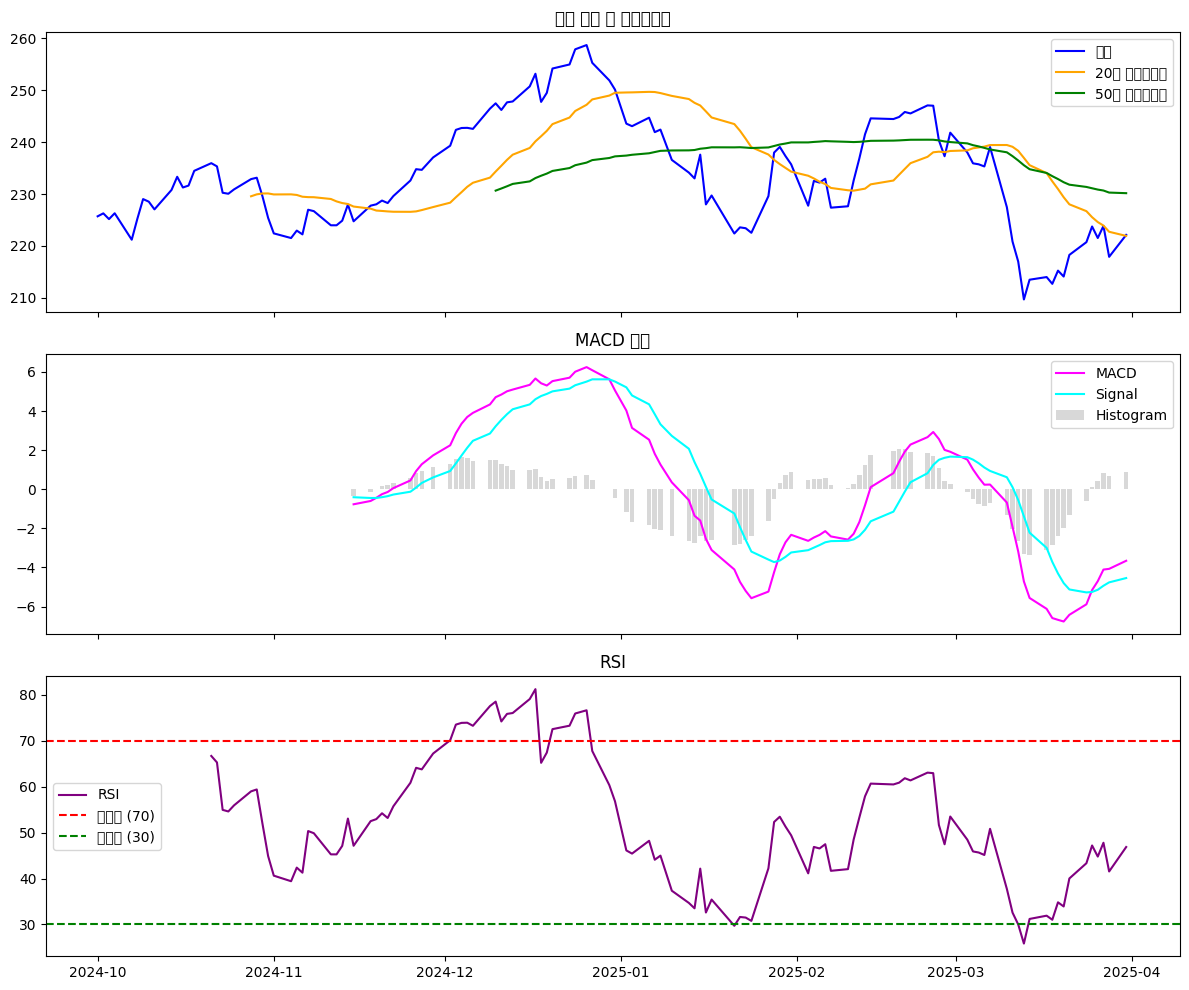

In [6]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df

def technical_analysis(df):
    analysis = {}
    
    # 이동평균선
    short_ma = talib.SMA(df['Close'], timeperiod=20)
    long_ma = talib.SMA(df['Close'], timeperiod=50)
    if short_ma.iloc[-1] > long_ma.iloc[-1]:
        analysis['이동평균선 추세'] = "상승세"
    else:
        analysis['이동평균선 추세'] = "하락세"
    
    # MACD 분석
    macd, signal, _ = talib.MACD(df['Close'])
    if macd.iloc[-1] > signal.iloc[-1]:
        analysis['MACD'] = "강세 신호"
    else:
        analysis['MACD'] = "약세 신호"
    
    # RSI 분석
    rsi = talib.RSI(df['Close'])
    if rsi.iloc[-1] > 70:
        analysis['RSI'] = "과매수"
    elif rsi.iloc[-1] < 30:
        analysis['RSI'] = "과매도"
    else:
        analysis['RSI'] = "중립"
    
    # OBV 분석
    obv = talib.OBV(df['Close'], df['Volume'])
    if obv.iloc[-1] > obv.iloc[-5]:
        analysis['OBV'] = "긍정적 흐름"
    else:
        analysis['OBV'] = "부정적 흐름"
    
    return analysis

def fundamental_analysis(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    info = stock.info
    analysis = {}
    
    # P/E, PBR 지표
    analysis['P/E'] = info.get('trailingPE', 'N/A')
    analysis['PBR'] = info.get('priceToBook', 'N/A')
    
    # 매출 성장률
    revenue_growth = info.get('revenueGrowth', None)
    if revenue_growth is not None:
        analysis['매출 성장'] = f"{revenue_growth * 100:.2f}%"
    else:
        analysis['매출 성장'] = "데이터 없음"
    
    # 순부채비율 (부채/자산 비율 확인)\n    \n    total_debt와 total_assets가 없는 경우 대비\n    \n    \n    \n"
    total_debt = info.get('totalDebt', 0)
    total_assets = info.get('totalAssets', None)
    if total_assets and total_assets > 0:
        debt_ratio = total_debt / total_assets
        analysis['순부채비율'] = f"{debt_ratio:.2%}"
    else:
        analysis['순부채비율'] = "데이터 없음"
    
    return analysis

def valuation_analysis(pe, pbr):
    if pe != 'N/A' and pbr != 'N/A':
        if pe > 25 or pbr > 3:
            return "고평가 가능성 있음"
        else:
            return "적정 가치"
    return "데이터 부족"

def plot_stock_analysis(df):
    # 계산된 기술적 지표 재계산
    short_ma = talib.SMA(df['Close'], timeperiod=20)
    long_ma = talib.SMA(df['Close'], timeperiod=50)
    macd, signal, hist = talib.MACD(df['Close'])
    rsi = talib.RSI(df['Close'])
    
    # 플롯 생성
    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)
    
    # 가격 및 이동평균선 플롯
    axs[0].plot(df.index, df['Close'], label="종가", color="blue")
    axs[0].plot(df.index, short_ma, label="20일 이동평균선", color="orange")
    axs[0].plot(df.index, long_ma, label="50일 이동평균선", color="green")
    axs[0].set_title("애플 주가 및 이동평균선")
    axs[0].legend()
    
    # MACD 플롯
    axs[1].plot(df.index, macd, label="MACD", color="magenta")
    axs[1].plot(df.index, signal, label="Signal", color="cyan")
    axs[1].bar(df.index, hist, label="Histogram", color="gray", alpha=0.3)
    axs[1].set_title("MACD 분석")
    axs[1].legend()
    
    # RSI 플롯
    axs[2].plot(df.index, rsi, label="RSI", color="purple")
    axs[2].axhline(70, color="red", linestyle="--", label="과매수 (70)")
    axs[2].axhline(30, color="green", linestyle="--", label="과매도 (30)")
    axs[2].set_title("RSI")
    axs[2].legend()
    
    plt.tight_layout()
    plt.show()

def summary_report():
    df = get_stock_data()
    tech_analysis = technical_analysis(df)
    fund_analysis = fundamental_analysis()
    valuation = valuation_analysis(fund_analysis['P/E'], fund_analysis['PBR'])
    
    report = "📊 **종합 분석 리포트**\n"
    report += f"**기술적 분석:** {tech_analysis}\n"
    report += f"**펀더멘탈 분석:** {fund_analysis}\n"
    report += f"**현재 가치 평가:** {valuation}\n"
    
    # 리포트 출력과 함께 시각화
    print(report)
    plot_stock_analysis(df)

# 실행
summary_report()


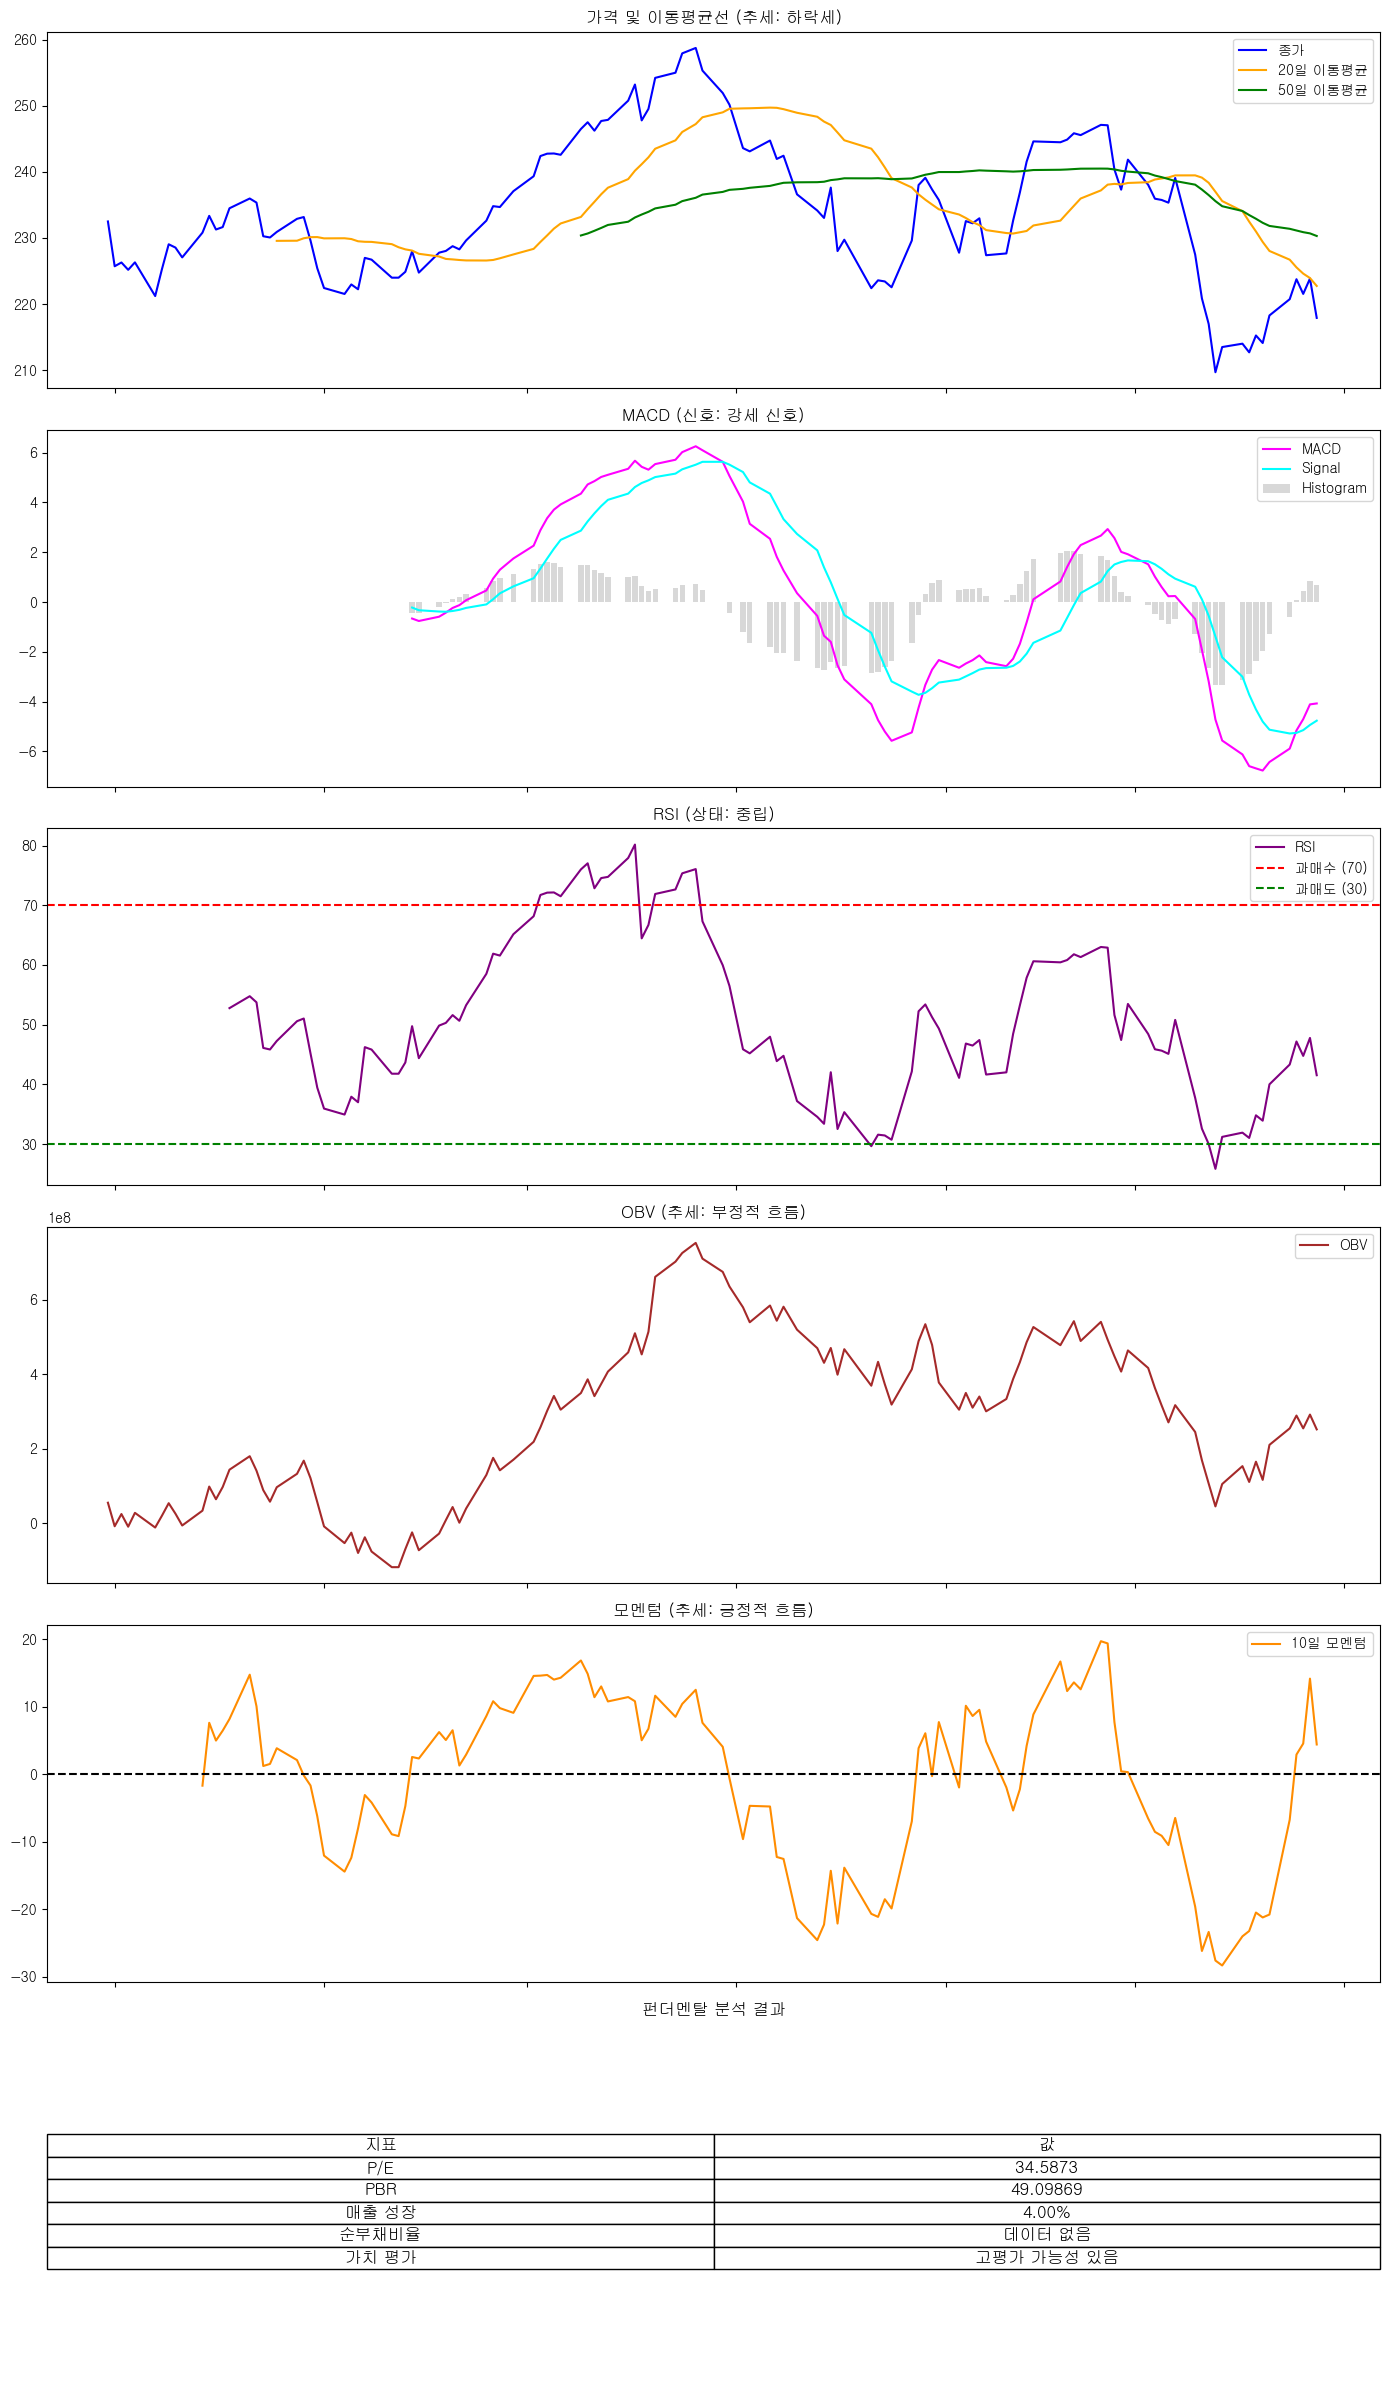

📊 **종합 분석 리포트**
    
[기술적 분석]
- 가격 이동평균선: 하락세
- MACD: 강세 신호
- RSI: 중립
- OBV: 부정적 흐름
- 모멘텀: 긍정적 흐름

[펀더멘탈 분석]
- P/E: 34.5873
- PBR: 49.09869
- 매출 성장: 4.00%
- 순부채비율: 데이터 없음
- 가치 평가: 고평가 가능성 있음
    


In [12]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df

def technical_analysis(df):
    analysis = {}
    # 이동평균선
    short_ma = talib.SMA(df['Close'], timeperiod=20)
    long_ma = talib.SMA(df['Close'], timeperiod=50)
    analysis['short_ma'] = short_ma
    analysis['long_ma'] = long_ma
    analysis['price_trend'] = "상승세" if short_ma.iloc[-1] > long_ma.iloc[-1] else "하락세"
    
    # MACD
    macd, signal, _ = talib.MACD(df['Close'])
    analysis['macd'] = macd
    analysis['signal'] = signal
    analysis['macd_trend'] = "강세 신호" if macd.iloc[-1] > signal.iloc[-1] else "약세 신호"
    
    # RSI
    rsi = talib.RSI(df['Close'])
    analysis['rsi'] = rsi
    if rsi.iloc[-1] > 70:
        analysis['rsi_status'] = "과매수"
    elif rsi.iloc[-1] < 30:
        analysis['rsi_status'] = "과매도"
    else:
        analysis['rsi_status'] = "중립"
    
    # OBV
    obv = talib.OBV(df['Close'], df['Volume'])
    analysis['obv'] = obv
    # 최근 5일간의 OBV 변화로 추세 판단
    analysis['obv_trend'] = "긍정적 흐름" if obv.iloc[-1] > obv.iloc[-5] else "부정적 흐름"
    
    # 모멘텀 (10일 기준)
    mom = talib.MOM(df['Close'], timeperiod=10)
    analysis['momentum'] = mom
    analysis['mom_trend'] = "긍정적 흐름" if mom.iloc[-1] > 0 else "부정적 흐름"
    
    return analysis

def fundamental_analysis(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    info = stock.info
    analysis = {}
    # P/E, PBR
    analysis['P/E'] = info.get('trailingPE', 'N/A')
    analysis['PBR'] = info.get('priceToBook', 'N/A')
    
    # 매출 성장률
    revenue_growth = info.get('revenueGrowth', None)
    if revenue_growth is not None:
        analysis['매출 성장'] = f"{revenue_growth * 100:.2f}%"
    else:
        analysis['매출 성장'] = "데이터 없음"
    
    # 순부채비율 (부채/자산 비율) 계산\n\n    totalDebt와 totalAssets 값이 없으면 데이터 없음으로 처리\n    \n"
    total_debt = info.get('totalDebt', 0)
    total_assets = info.get('totalAssets', None)
    if total_assets and total_assets > 0:
        debt_ratio = total_debt / total_assets
        analysis['순부채비율'] = f"{debt_ratio:.2%}"
    else:
        analysis['순부채비율'] = "데이터 없음"
    
    return analysis

def valuation_analysis(pe, pbr):
    if pe != 'N/A' and pbr != 'N/A':
        if pe > 25 or pbr > 3:
            return "고평가 가능성 있음"
        else:
            return "적정 가치"
    return "데이터 부족"

def plot_all_indicators():
    df = get_stock_data()
    tech = technical_analysis(df)
    fund = fundamental_analysis()
    valuation = valuation_analysis(fund['P/E'], fund['PBR'])
    
    # 전체 그림: 6행 1열 서브플롯 (마지막 행은 펀더멘탈 결과 테이블)
    fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(14, 24), sharex=True)
    
    # 1. 가격 및 이동평균선 플롯
    axs[0].plot(df.index, df['Close'], label="종가", color="blue")
    axs[0].plot(df.index, tech['short_ma'], label="20일 이동평균", color="orange")
    axs[0].plot(df.index, tech['long_ma'], label="50일 이동평균", color="green")
    axs[0].set_title("가격 및 이동평균선 (추세: {})".format(tech['price_trend']))
    axs[0].legend()
    
    # 2. MACD 플롯
    axs[1].plot(df.index, tech['macd'], label="MACD", color="magenta")
    axs[1].plot(df.index, tech['signal'], label="Signal", color="cyan")
    axs[1].bar(df.index, tech['macd'] - tech['signal'], label="Histogram", color="gray", alpha=0.3)
    axs[1].set_title("MACD (신호: {})".format(tech['macd_trend']))
    axs[1].legend()
    
    # 3. RSI 플롯
    axs[2].plot(df.index, tech['rsi'], label="RSI", color="purple")
    axs[2].axhline(70, color="red", linestyle="--", label="과매수 (70)")
    axs[2].axhline(30, color="green", linestyle="--", label="과매도 (30)")
    axs[2].set_title("RSI (상태: {})".format(tech['rsi_status']))
    axs[2].legend()
    
    # 4. OBV 플롯
    axs[3].plot(df.index, tech['obv'], label="OBV", color="brown")
    axs[3].set_title("OBV (추세: {})".format(tech['obv_trend']))
    axs[3].legend()
    
    # 5. 모멘텀 플롯
    axs[4].plot(df.index, tech['momentum'], label="10일 모멘텀", color="darkorange")
    axs[4].axhline(0, color="black", linestyle="--")
    axs[4].set_title("모멘텀 (추세: {})".format(tech['mom_trend']))
    axs[4].legend()
    
    # 6. 펀더멘탈 분석 결과를 테이블 형태로 출력
    axs[5].axis('off')  # 축 숨김
    table_data = [
        ["P/E", fund['P/E']],
        ["PBR", fund['PBR']],
        ["매출 성장", fund['매출 성장']],
        ["순부채비율", fund['순부채비율']],
        ["가치 평가", valuation]
    ]
    table = axs[5].table(cellText=table_data, colLabels=["지표", "값"], cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    axs[5].set_title("펀더멘탈 분석 결과", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    # 텍스트 리포트 출력
    report = f"""📊 **종합 분석 리포트**
    
[기술적 분석]
- 가격 이동평균선: {tech['price_trend']}
- MACD: {tech['macd_trend']}
- RSI: {tech['rsi_status']}
- OBV: {tech['obv_trend']}
- 모멘텀: {tech['mom_trend']}

[펀더멘탈 분석]
- P/E: {fund['P/E']}
- PBR: {fund['PBR']}
- 매출 성장: {fund['매출 성장']}
- 순부채비율: {fund['순부채비율']}
- 가치 평가: {valuation}
    """
    print(report)

# 실행
plot_all_indicators()


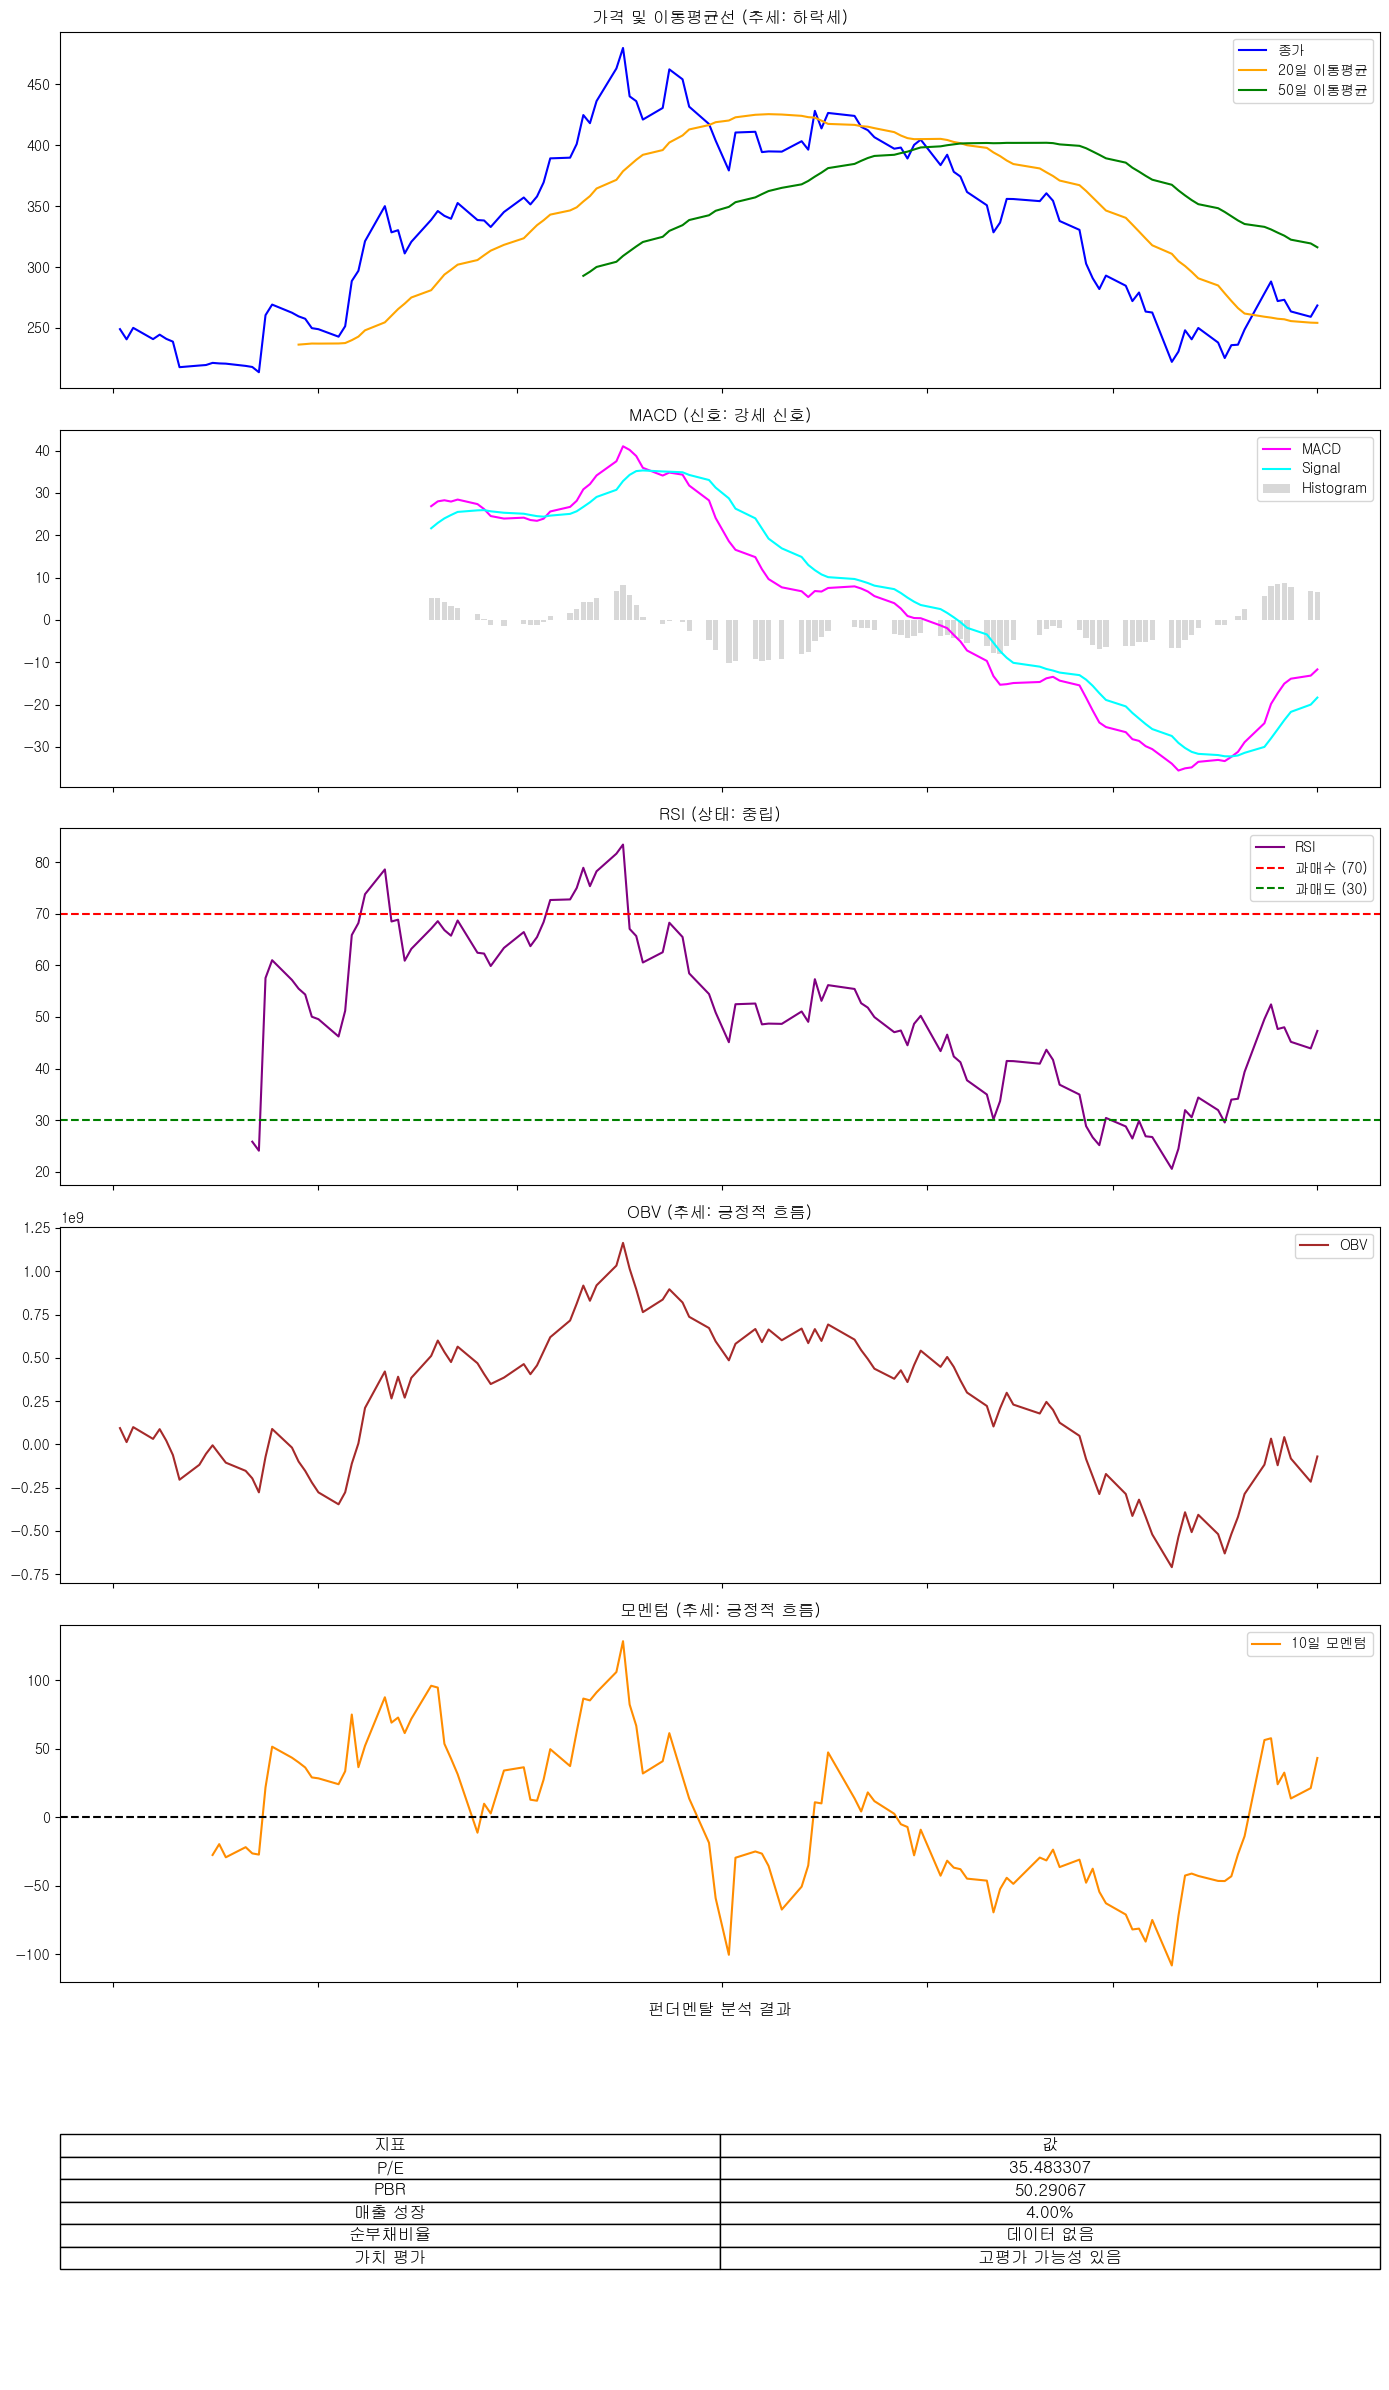

📊 **종합 분석 리포트**
    
[기술적 분석]
- 가격 이동평균선: 하락세
- MACD: 강세 신호
- RSI: 중립
- OBV: 긍정적 흐름
- 모멘텀: 긍정적 흐름

[펀더멘탈 분석]
- P/E: 35.483307
- PBR: 50.29067
- 매출 성장: 4.00%
- 순부채비율: 데이터 없음
- 가치 평가: 고평가 가능성 있음
    


In [4]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_stock_data(ticker="TSLA", period="6mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df

def technical_analysis(df):
    analysis = {}
    # 이동평균선
    short_ma = talib.SMA(df['Close'], timeperiod=20)
    long_ma = talib.SMA(df['Close'], timeperiod=50)
    analysis['short_ma'] = short_ma
    analysis['long_ma'] = long_ma
    analysis['price_trend'] = "상승세" if short_ma.iloc[-1] > long_ma.iloc[-1] else "하락세"
    
    # MACD
    macd, signal, _ = talib.MACD(df['Close'])
    analysis['macd'] = macd
    analysis['signal'] = signal
    analysis['macd_trend'] = "강세 신호" if macd.iloc[-1] > signal.iloc[-1] else "약세 신호"
    
    # RSI
    rsi = talib.RSI(df['Close'])
    analysis['rsi'] = rsi
    if rsi.iloc[-1] > 70:
        analysis['rsi_status'] = "과매수"
    elif rsi.iloc[-1] < 30:
        analysis['rsi_status'] = "과매도"
    else:
        analysis['rsi_status'] = "중립"
    
    # OBV
    obv = talib.OBV(df['Close'], df['Volume'])
    analysis['obv'] = obv
    # 최근 5일간의 OBV 변화로 추세 판단
    analysis['obv_trend'] = "긍정적 흐름" if obv.iloc[-1] > obv.iloc[-5] else "부정적 흐름"
    
    # 모멘텀 (10일 기준)
    mom = talib.MOM(df['Close'], timeperiod=10)
    analysis['momentum'] = mom
    analysis['mom_trend'] = "긍정적 흐름" if mom.iloc[-1] > 0 else "부정적 흐름"
    
    return analysis

def fundamental_analysis(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    info = stock.info
    analysis = {}
    # P/E, PBR
    analysis['P/E'] = info.get('trailingPE', 'N/A')
    analysis['PBR'] = info.get('priceToBook', 'N/A')
    
    # 매출 성장률
    revenue_growth = info.get('revenueGrowth', None)
    if revenue_growth is not None:
        analysis['매출 성장'] = f"{revenue_growth * 100:.2f}%"
    else:
        analysis['매출 성장'] = "데이터 없음"
    
    # 순부채비율 (부채/자산 비율) 계산\n\n    totalDebt와 totalAssets 값이 없으면 데이터 없음으로 처리\n    \n"
    total_debt = info.get('totalDebt', 0)
    total_assets = info.get('totalAssets', None)
    if total_assets and total_assets > 0:
        debt_ratio = total_debt / total_assets
        analysis['순부채비율'] = f"{debt_ratio:.2%}"
    else:
        analysis['순부채비율'] = "데이터 없음"
    
    return analysis

def valuation_analysis(pe, pbr):
    if pe != 'N/A' and pbr != 'N/A':
        if pe > 25 or pbr > 3:
            return "고평가 가능성 있음"
        else:
            return "적정 가치"
    return "데이터 부족"

def plot_all_indicators():
    df = get_stock_data()
    tech = technical_analysis(df)
    fund = fundamental_analysis()
    valuation = valuation_analysis(fund['P/E'], fund['PBR'])
    
    # 전체 그림: 6행 1열 서브플롯 (마지막 행은 펀더멘탈 결과 테이블)
    fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(14, 24), sharex=True)
    
    # 1. 가격 및 이동평균선 플롯
    axs[0].plot(df.index, df['Close'], label="종가", color="blue")
    axs[0].plot(df.index, tech['short_ma'], label="20일 이동평균", color="orange")
    axs[0].plot(df.index, tech['long_ma'], label="50일 이동평균", color="green")
    axs[0].set_title("가격 및 이동평균선 (추세: {})".format(tech['price_trend']))
    axs[0].legend()
    
    # 2. MACD 플롯
    axs[1].plot(df.index, tech['macd'], label="MACD", color="magenta")
    axs[1].plot(df.index, tech['signal'], label="Signal", color="cyan")
    axs[1].bar(df.index, tech['macd'] - tech['signal'], label="Histogram", color="gray", alpha=0.3)
    axs[1].set_title("MACD (신호: {})".format(tech['macd_trend']))
    axs[1].legend()
    
    # 3. RSI 플롯
    axs[2].plot(df.index, tech['rsi'], label="RSI", color="purple")
    axs[2].axhline(70, color="red", linestyle="--", label="과매수 (70)")
    axs[2].axhline(30, color="green", linestyle="--", label="과매도 (30)")
    axs[2].set_title("RSI (상태: {})".format(tech['rsi_status']))
    axs[2].legend()
    
    # 4. OBV 플롯
    axs[3].plot(df.index, tech['obv'], label="OBV", color="brown")
    axs[3].set_title("OBV (추세: {})".format(tech['obv_trend']))
    axs[3].legend()
    
    # 5. 모멘텀 플롯
    axs[4].plot(df.index, tech['momentum'], label="10일 모멘텀", color="darkorange")
    axs[4].axhline(0, color="black", linestyle="--")
    axs[4].set_title("모멘텀 (추세: {})".format(tech['mom_trend']))
    axs[4].legend()
    
    # 6. 펀더멘탈 분석 결과를 테이블 형태로 출력
    axs[5].axis('off')  # 축 숨김
    table_data = [
        ["P/E", fund['P/E']],
        ["PBR", fund['PBR']],
        ["매출 성장", fund['매출 성장']],
        ["순부채비율", fund['순부채비율']],
        ["가치 평가", valuation]
    ]
    table = axs[5].table(cellText=table_data, colLabels=["지표", "값"], cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    axs[5].set_title("펀더멘탈 분석 결과", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    # 텍스트 리포트 출력
    report = f"""📊 **종합 분석 리포트**
    
[기술적 분석]
- 가격 이동평균선: {tech['price_trend']}
- MACD: {tech['macd_trend']}
- RSI: {tech['rsi_status']}
- OBV: {tech['obv_trend']}
- 모멘텀: {tech['mom_trend']}

[펀더멘탈 분석]
- P/E: {fund['P/E']}
- PBR: {fund['PBR']}
- 매출 성장: {fund['매출 성장']}
- 순부채비율: {fund['순부채비율']}
- 가치 평가: {valuation}
    """
    print(report)

# 실행
plot_all_indicators()


In [2]:
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
font_list

['cmss10',
 'STIXGeneral',
 'STIXGeneral',
 'cmr10',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'STIXSizeFiveSym',
 'DejaVu Serif Display',
 'STIXSizeThreeSym',
 'DejaVu Serif',
 'STIXSizeTwoSym',
 'DejaVu Sans Mono',
 'cmmi10',
 'STIXNonUnicode',
 'cmex10',
 'STIXNonUnicode',
 'STIXSizeFourSym',
 'DejaVu Sans Mono',
 'STIXNonUnicode',
 'STIXSizeTwoSym',
 'STIXSizeFourSym',
 'cmb10',
 'DejaVu Sans Display',
 'STIXNonUnicode',
 'STIXSizeOneSym',
 'DejaVu Serif',
 'DejaVu Sans',
 'STIXSizeOneSym',
 'DejaVu Serif',
 'DejaVu Sans Mono',
 'cmsy10',
 'STIXGeneral',
 'STIXSizeThreeSym',
 'DejaVu Sans',
 'cmtt10',
 'DejaVu Sans',
 'DejaVu Sans',
 'STIXGeneral',
 'Candara',
 'Agency FB',
 'Bodoni MT',
 'Consolas',
 'Informal Roman',
 'Myanmar Text',
 'Gulim',
 'Ebrima',
 'Elephant',
 'Arial',
 'Batang',
 'Pyunji R',
 'Gill Sans Ultra Bold Condensed',
 'Perpetua Titling MT',
 'Microsoft PhagsPa',
 'Consolas',
 'Perpetua Titling MT',
 'Microsoft Tai Le',
 'Tw Cen MT Condensed',
 'Palatino Linotype',


In [3]:
plt.rcParams['font.family'] = 'Gulim'

In [13]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df

def technical_analysis(df):
    analysis = {}
    # 이동평균선
    short_ma = talib.SMA(df['Close'], timeperiod=20)
    long_ma = talib.SMA(df['Close'], timeperiod=50)
    analysis['short_ma'] = short_ma
    analysis['long_ma'] = long_ma
    analysis['price_trend'] = "상승세" if short_ma.iloc[-1] > long_ma.iloc[-1] else "하락세"
    
    # MACD
    macd, signal, _ = talib.MACD(df['Close'])
    analysis['macd'] = macd
    analysis['signal'] = signal
    analysis['macd_trend'] = "강세 신호" if macd.iloc[-1] > signal.iloc[-1] else "약세 신호"
    
    # RSI
    rsi = talib.RSI(df['Close'])
    analysis['rsi'] = rsi
    if rsi.iloc[-1] > 70:
        analysis['rsi_status'] = "과매수"
    elif rsi.iloc[-1] < 30:
        analysis['rsi_status'] = "과매도"
    else:
        analysis['rsi_status'] = "중립"
    
    # OBV
    obv = talib.OBV(df['Close'], df['Volume'])
    analysis['obv'] = obv
    analysis['obv_trend'] = "긍정적 흐름" if obv.iloc[-1] > obv.iloc[-5] else "부정적 흐름"
    
    # 모멘텀 (10일 기준)
    mom = talib.MOM(df['Close'], timeperiod=10)
    analysis['momentum'] = mom
    analysis['mom_trend'] = "긍정적 흐름" if mom.iloc[-1] > 0 else "부정적 흐름"
    
    return analysis

def fundamental_analysis(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    info = stock.info
    analysis = {}
    # P/E, PBR
    analysis['P/E'] = info.get('trailingPE', 'N/A')
    analysis['PBR'] = info.get('priceToBook', 'N/A')
    
    # 매출 성장률
    revenue_growth = info.get('revenueGrowth', None)
    if revenue_growth is not None:
        analysis['매출 성장'] = f"{revenue_growth * 100:.2f}%"
    else:
        analysis['매출 성장'] = "데이터 없음"
    
    # 순부채비율 (부채/자산 비율) 계산\n    \n    totalDebt와 totalAssets 값이 없으면 데이터 없음으로 처리\n    \n"
    total_debt = info.get('totalDebt', 0)
    total_assets = info.get('totalAssets', None)
    if total_assets and total_assets > 0:
        debt_ratio = total_debt / total_assets
        analysis['순부채비율'] = f"{debt_ratio:.2%}"
    else:
        analysis['순부채비율'] = "데이터 없음"
    
    return analysis

def valuation_analysis(pe, pbr):
    if pe != 'N/A' and pbr != 'N/A':
        if pe > 25 or pbr > 3:
            return "고평가 가능성 있음"
        else:
            return "적정 가치"
    return "데이터 부족"

def generate_total_comment(tech, fund, valuation):
    """
    기술적, 펀더멘탈 분석 결과를 종합하여 최종 총평을 생성합니다.
    예시: 기술적으로는 하락세이나, 펀더멘탈 측면에서는 매출 성장 등 긍정적인 흐름을 보입니다.
          그러나 고평가 우려와 단기 시장 약세를 고려하면 보수적인 관망 전략이 필요합니다.
    """
    comment = ""
    # 기술적 분석 총평
    comment += f"기술적 분석 결과, 가격 이동평균선은 {tech['price_trend']}, MACD는 {tech['macd_trend']}, "
    comment += f"RSI는 {tech['rsi_status']}, OBV는 {tech['obv_trend']}, 모멘텀은 {tech['mom_trend']}입니다.\n"
    
    # 펀더멘탈 분석 총평
    comment += f"펀더멘탈 분석에서는 P/E가 {fund['P/E']}, PBR이 {fund['PBR']}, 매출 성장률은 {fund['매출 성장']}, "
    comment += f"순부채비율은 {fund['순부채비율']}로 나타났으며, 전반적으로 {valuation} 상태입니다.\n"
    
    # 종합 총평
    if tech['price_trend'] == "하락세" or tech['macd_trend'] == "약세 신호" or tech['rsi_status'] == "과매도":
        tech_comment = "단기적으로 약세 신호가 포착되고 있으므로 주의가 필요합니다."
    else:
        tech_comment = "단기적으로 강세 신호가 관찰됩니다."
    
    if valuation == "고평가 가능성 있음":
        fund_comment = "하지만 펀더멘탈 측면에서는 고평가 우려가 있어 신중한 접근이 필요합니다."
    else:
        fund_comment = "펀더멘탈 지표는 안정적인 흐름을 보여줍니다."
    
    comment += f"\n종합 총평: {tech_comment} {fund_comment} 전반적으로 보수적인 관망 전략을 권장합니다."
    return comment

def plot_all_indicators():
    df = get_stock_data()
    tech = technical_analysis(df)
    fund = fundamental_analysis()
    valuation = valuation_analysis(fund['P/E'], fund['PBR'])
    
    # 총 7행 1열 서브플롯 (마지막 두 행은 펀더멘탈 결과 테이블과 종합 총평)
    fig, axs = plt.subplots(nrows=7, ncols=1, figsize=(14, 28), sharex=True)
    
    # 1. 가격 및 이동평균선 플롯
    axs[0].plot(df.index, df['Close'], label="종가", color="blue")
    axs[0].plot(df.index, tech['short_ma'], label="20일 이동평균", color="orange")
    axs[0].plot(df.index, tech['long_ma'], label="50일 이동평균", color="green")
    axs[0].set_title("가격 및 이동평균선 (추세: {})".format(tech['price_trend']))
    axs[0].legend()
    
    # 2. MACD 플롯
    axs[1].plot(df.index, tech['macd'], label="MACD", color="magenta")
    axs[1].plot(df.index, tech['signal'], label="Signal", color="cyan")
    axs[1].bar(df.index, tech['macd'] - tech['signal'], label="Histogram", color="gray", alpha=0.3)
    axs[1].set_title("MACD (신호: {})".format(tech['macd_trend']))
    axs[1].legend()
    
    # 3. RSI 플롯
    axs[2].plot(df.index, tech['rsi'], label="RSI", color="purple")
    axs[2].axhline(70, color="red", linestyle="--", label="과매수 (70)")
    axs[2].axhline(30, color="green", linestyle="--", label="과매도 (30)")
    axs[2].set_title("RSI (상태: {})".format(tech['rsi_status']))
    axs[2].legend()
    
    # 4. OBV 플롯
    axs[3].plot(df.index, tech['obv'], label="OBV", color="brown")
    axs[3].set_title("OBV (추세: {})".format(tech['obv_trend']))
    axs[3].legend()
    
    # 5. 모멘텀 플롯
    axs[4].plot(df.index, tech['momentum'], label="10일 모멘텀", color="darkorange")
    axs[4].axhline(0, color="black", linestyle="--")
    axs[4].set_title("모멘텀 (추세: {})".format(tech['mom_trend']))
    axs[4].legend()
    
    # 6. 펀더멘탈 분석 결과를 테이블 형태로 출력
    axs[5].axis('off')  # 축 숨김
    table_data = [
        ["P/E", fund['P/E']],
        ["PBR", fund['PBR']],
        ["매출 성장", fund['매출 성장']],
        ["순부채비율", fund['순부채비율']],
        ["가치 평가", valuation]
    ]
    table = axs[5].table(cellText=table_data, colLabels=["지표", "값"], cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    axs[5].set_title("펀더멘탈 분석 결과", fontweight="bold")
    
    # 7. 종합 총평 텍스트 출력
    axs[6].axis('off')  # 축 숨김
    total_comment = generate_total_comment(tech, fund, valuation)
    axs[6].text(0.5, 0.5, total_comment, fontsize=12, ha='center', va='center', wrap=True)
    axs[6].set_title("종합 총평", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    # 콘솔에도 최종 리포트 출력
    report = f"""📊 **종합 분석 리포트**
    
[기술적 분석]
- 가격 이동평균선: {tech['price_trend']}
- MACD: {tech['macd_trend']}
- RSI: {tech['rsi_status']}
- OBV: {tech['obv_trend']}
- 모멘텀: {tech['mom_trend']}

[펀더멘탈 분석]
- P/E: {fund['P/E']}
- PBR: {fund['PBR']}
- 매출 성장: {fund['매출 성장']}
- 순부채비율: {fund['순부채비율']}
- 가치 평가: {valuation}

[종합 총평]
{generate_total_comment(tech, fund, valuation)}
    """
    print(report)

# 실행
plot_all_indicators()


C:\Users\dmlxo\AppData\Local\Temp\ipykernel_480\1828924180.py:174: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


📊 **종합 분석 리포트**
    
[기술적 분석]
- 가격 이동평균선: 하락세
- MACD: 강세 신호
- RSI: 중립
- OBV: 부정적 흐름
- 모멘텀: 긍정적 흐름

[펀더멘탈 분석]
- P/E: 34.5873
- PBR: 49.09869
- 매출 성장: 4.00%
- 순부채비율: 데이터 없음
- 가치 평가: 고평가 가능성 있음

[종합 총평]
기술적 분석 결과, 가격 이동평균선은 하락세, MACD는 강세 신호, RSI는 중립, OBV는 부정적 흐름, 모멘텀은 긍정적 흐름입니다.
펀더멘탈 분석에서는 P/E가 34.5873, PBR이 49.09869, 매출 성장률은 4.00%, 순부채비율은 데이터 없음로 나타났으며, 전반적으로 고평가 가능성 있음 상태입니다.

종합 총평: 단기적으로 약세 신호가 포착되고 있으므로 주의가 필요합니다. 하지만 펀더멘탈 측면에서는 고평가 우려가 있어 신중한 접근이 필요합니다. 전반적으로 보수적인 관망 전략을 권장합니다.
    


In [17]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2430489761.py:83: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2430489761.py:83: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2430489761.py:83: UserWarning: Glyph 48143 (\N{HANGUL SYLLABLE MIC}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2430489761.py:83: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2430489761.py:83: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_1528\2430489761.py:83: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  plt.tight_layout(

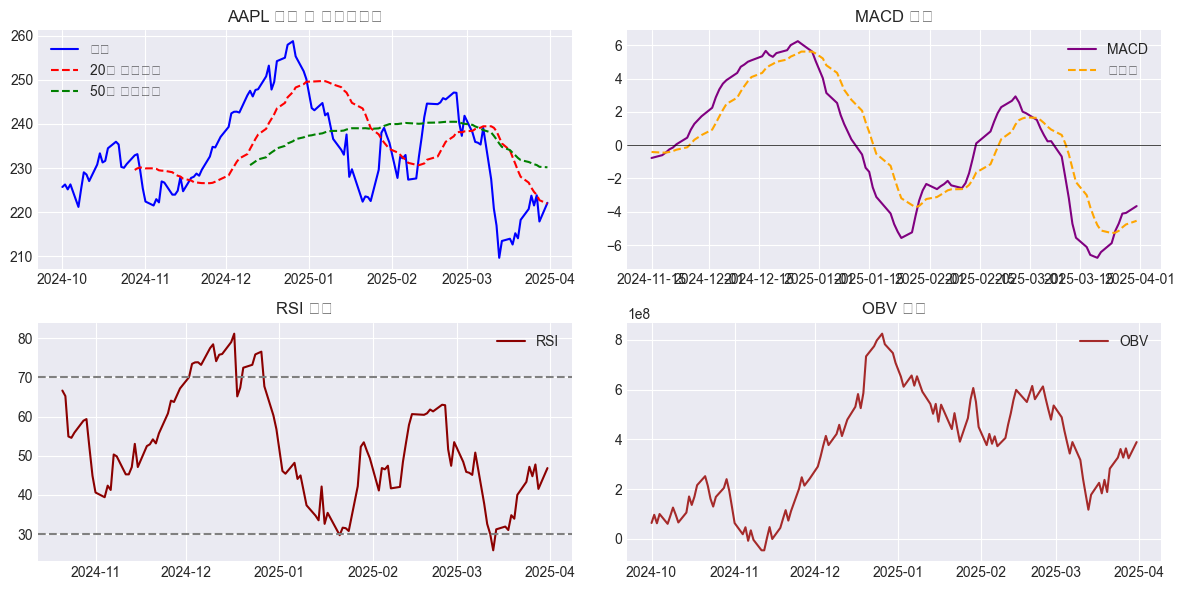


    📌 **AAPL 주식 종합 분석**
    ✅ **기술적 분석**
    - 현재 주가 흐름: 하락세
    - MACD 분석: 강세 신호
    - RSI 상태: 중립

    ✅ **펀더멘털 분석**
    - 매출 성장률: 4.00%
    - P/E 비율: 35.26
    - PBR 비율: 50.05
    - 재무 건전성: 부채 위험
    - 현재 주가는 고평가 상태입니다.

    🔥 **총평:** 기술적으로 하락세이며, MACD는 강세 신호를 나타내고 있습니다.
    RSI 기준으로는 중립 상태이며, 고평가 측면에서 부채 위험 평가를 받고 있습니다.
    따라서, **단기 매매보다 보수적인 접근이 필요**할 수 있습니다.
    


In [8]:
# 필요한 라이브러리 불러오기
import yfinance as yf
import talib as ta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter Notebook에서 그래프 표시
%matplotlib inline

# 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')

# 📌 1. 주가 데이터 가져오기
def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    return df

# 📌 2. 기술적 분석 수행
def technical_analysis(df):
    df["SMA_20"] = ta.SMA(df["Close"], timeperiod=20)  # 20일 이동평균
    df["SMA_50"] = ta.SMA(df["Close"], timeperiod=50)  # 50일 이동평균
    df["MACD"], df["MACD_Signal"], _ = ta.MACD(df["Close"])
    df["RSI"] = ta.RSI(df["Close"])
    df["OBV"] = ta.OBV(df["Close"], df["Volume"])
    return df

# 📌 3. 펀더멘털 분석 수행
def fundamental_analysis(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    info = stock.info
    
    # P/E, PBR, 매출 성장률, 부채비율 등 추출
    pe_ratio = info.get("trailingPE", np.nan)
    pb_ratio = info.get("priceToBook", np.nan)
    revenue_growth = info.get("revenueGrowth", np.nan)
    debt_to_equity = info.get("debtToEquity", np.nan)

    return {
        "P/E Ratio": pe_ratio,
        "PBR": pb_ratio,
        "Revenue Growth": revenue_growth,
        "Debt-to-Equity": debt_to_equity
    }

# 📌 4. 시각적 자료 출력
def plot_technical_charts(df):
    plt.figure(figsize=(12, 6))

    # 1️⃣ 이동 평균선 그래프
    plt.subplot(2, 2, 1)
    plt.plot(df.index, df["Close"], label="종가", color='blue')
    plt.plot(df.index, df["SMA_20"], label="20일 이동평균", linestyle="dashed", color='red')
    plt.plot(df.index, df["SMA_50"], label="50일 이동평균", linestyle="dashed", color='green')
    plt.title("AAPL 주가 및 이동평균선")
    plt.legend()

    # 2️⃣ MACD 그래프
    plt.subplot(2, 2, 2)
    plt.plot(df.index, df["MACD"], label="MACD", color='purple')
    plt.plot(df.index, df["MACD_Signal"], label="신호선", linestyle="dashed", color='orange')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title("MACD 지표")
    plt.legend()

    # 3️⃣ RSI 그래프
    plt.subplot(2, 2, 3)
    plt.plot(df.index, df["RSI"], label="RSI", color='darkred')
    plt.axhline(70, color='gray', linestyle="dashed")
    plt.axhline(30, color='gray', linestyle="dashed")
    plt.title("RSI 지표")
    plt.legend()

    # 4️⃣ OBV 그래프
    plt.subplot(2, 2, 4)
    plt.plot(df.index, df["OBV"], label="OBV", color='brown')
    plt.title("OBV 지표")
    plt.legend()

    # 그래프 출력
    plt.tight_layout()
    plt.show()

# 📌 5. 종합 분석 & 총평
def generate_summary(df, fundamentals):
    last_rsi = df["RSI"].iloc[-1]
    last_macd = df["MACD"].iloc[-1]
    last_macd_signal = df["MACD_Signal"].iloc[-1]
    pe_ratio = fundamentals["P/E Ratio"]
    pb_ratio = fundamentals["PBR"]
    revenue_growth = fundamentals["Revenue Growth"]
    debt_to_equity = fundamentals["Debt-to-Equity"]

    # 📊 기술적 분석 평가
    trend = "상승세" if df["SMA_20"].iloc[-1] > df["SMA_50"].iloc[-1] else "하락세"
    macd_trend = "강세 신호" if last_macd > last_macd_signal else "약세 신호"
    rsi_status = "과매수" if last_rsi > 70 else "과매도" if last_rsi < 30 else "중립"

    # 📈 펀더멘털 분석 평가
    valuation = "고평가" if pe_ratio > 25 or pb_ratio > 3 else "저평가" if pe_ratio < 15 and pb_ratio < 1.5 else "적정가"
    financial_health = "양호" if debt_to_equity < 1 else "부채 위험"

    # 종합 평가 출력
    summary = f"""
    📌 **AAPL 주식 종합 분석**
    ✅ **기술적 분석**
    - 현재 주가 흐름: {trend}
    - MACD 분석: {macd_trend}
    - RSI 상태: {rsi_status}

    ✅ **펀더멘털 분석**
    - 매출 성장률: {revenue_growth:.2%}
    - P/E 비율: {pe_ratio:.2f}
    - PBR 비율: {pb_ratio:.2f}
    - 재무 건전성: {financial_health}
    - 현재 주가는 {valuation} 상태입니다.

    🔥 **총평:** 기술적으로 {trend}이며, MACD는 {macd_trend}를 나타내고 있습니다.
    RSI 기준으로는 {rsi_status} 상태이며, {valuation} 측면에서 {financial_health} 평가를 받고 있습니다.
    따라서, **단기 매매보다 보수적인 접근이 필요**할 수 있습니다.
    """

    print(summary)

# 📌 6. 실행
ticker = "AAPL"
df = get_stock_data(ticker)
df = technical_analysis(df)
fundamentals = fundamental_analysis(ticker)

# 그래프 출력
plot_technical_charts(df)

# 종합 분석 및 평가 출력
generate_summary(df, fundamentals)


In [22]:
import matplotlib.pyplot as plt

print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
